# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Read the data from the csv file into dataframe df
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/foodhub_order.csv')

In [6]:
# To view the first 5 rows of the foodhub dataset
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [12]:
# To display the number of rows and columns in the foodhub_order dataset.
df.shape

(1898, 9)

#### Observations:


There are 1898 rows and 9 columns in the foodhub dataset.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [13]:
# To view all the columns,datatypes and Nullable/Not Nullable columns of the foodhub dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


There are 4 integer datatypes , one float datatype and 4 object type datatype. All are not null columns in the dataset.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Find the missing values for all the columns
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:


There are no missing values in the data.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Check the statistical summary of the data
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations:


The time it takes to prepare the food once order is places:
Minimum Time (in minutes) - 20.0 minutes
Average Time (in minutes) - 27.37197 minutes
Maximum Time (in minutes) - 35.0 minutes

### **Question 5:** How many orders are not rated? [1 mark]

In [14]:
# Get the distinct counts of Rating category
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:


There are 736 orders whcich do not have order rated.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

###**`Order ID`**

In [23]:
# Analyze the unique number of order ids.
df['order_id'].nunique()

1898

###**`Observations:`**
There are 1898 unique number order ids in the foodhub dataset.

###**`Customer ID`**



In [24]:
# Analyze the unique number of customer ids.
df['customer_id'].nunique()

1200

###**`Observations:`**
There are 1200 unique customers in the foodhub dataset. There are customers who placed multiple orders.

###**`Restuarant Name`**

In [30]:
# Check the unique number of restaurant names.
df['restaurant_name'].nunique()

178

###**`Observations:`** There are 178 unique restauants in the foodhub dataset.

###**`Cuisine Type`**

In [32]:
# Check the various types of cuisine
df['cuisine_type'].unique()

array(['Korean', 'Japanese', 'Mexican', 'American', 'Indian', 'Italian',
       'Mediterranean', 'Chinese', 'Middle Eastern', 'Thai', 'Southern',
       'French', 'Spanish', 'Vietnamese'], dtype=object)

In [33]:
# Check the number of types of cuisine
df['cuisine_type'].nunique()

14

###**`Observations:`**

*  There are 14 unique cuisine types in the foodhub dataset.
*  The different cuisines are: 'Korean', 'Japanese', 'Mexican', 'American', 'Indian', 'Italian','Mediterranean', 'Chinese', 'Middle Eastern', 'Thai','Southern','French', 'Spanish', 'Vietnamese'.

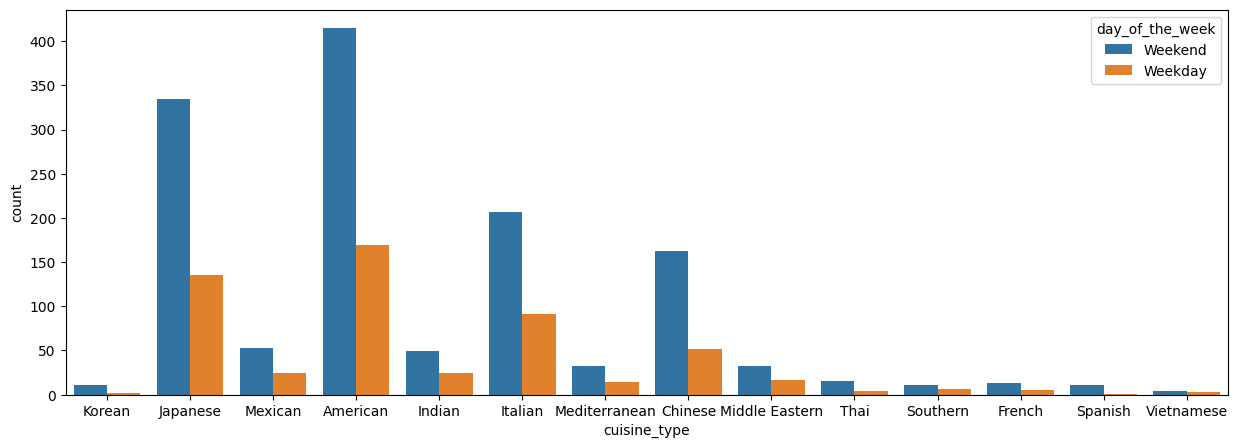

In [29]:
# Visualize the cuisine types and their orders.
plt.figure(figsize = (15,5))
sns.countplot(data = df, x = 'cuisine_type',hue='day_of_the_week');

###**`Observations:`**


*   The American cuisine is the most popular cuisine ordered in weekdays and weekends
*   The Vietnamese cuisine is the least ordered cuisine.
*   Top 3 ordered cuisines are American, Japanese and Italian.




###**`Cost of the Order`**

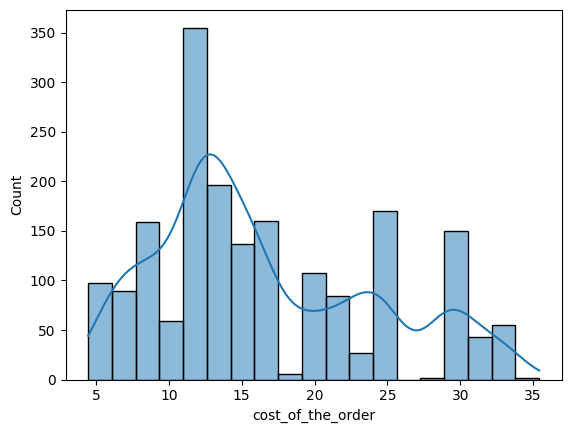

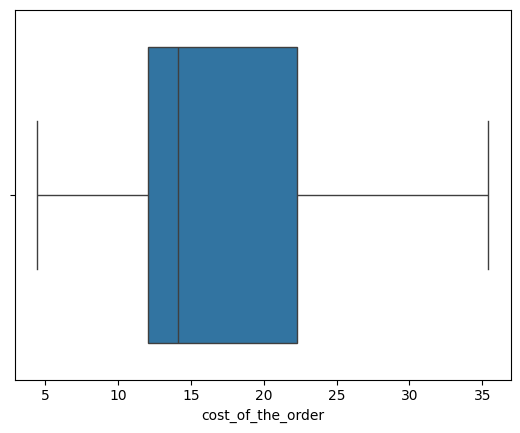

In [8]:
sns.histplot(data=df,x='cost_of_the_order',kde=True) ## Histogram for the cost of order
plt.show()
sns.boxplot(data=df,x='cost_of_the_order') ## Boxplot for the cost of order
plt.show()

###**`Observations:`**

*   The cost of the order is positively skewed (skewed right).
*   The minimum cost of orders is 4.47 dollars, Q1 (Quantile 25%) is 12.08 dollars,median is 14.14 dollars, Q3(Quantile 75%) is 22.2975 and maximum is 35.41 dollars. There are no outliers for the cost of order.




###**`Day of the week`**

In [10]:
# # Check the unique values for the day_of_week
df['day_of_the_week'].value_counts()

,count
day_of_the_week,
Weekend,1351
Weekday,547


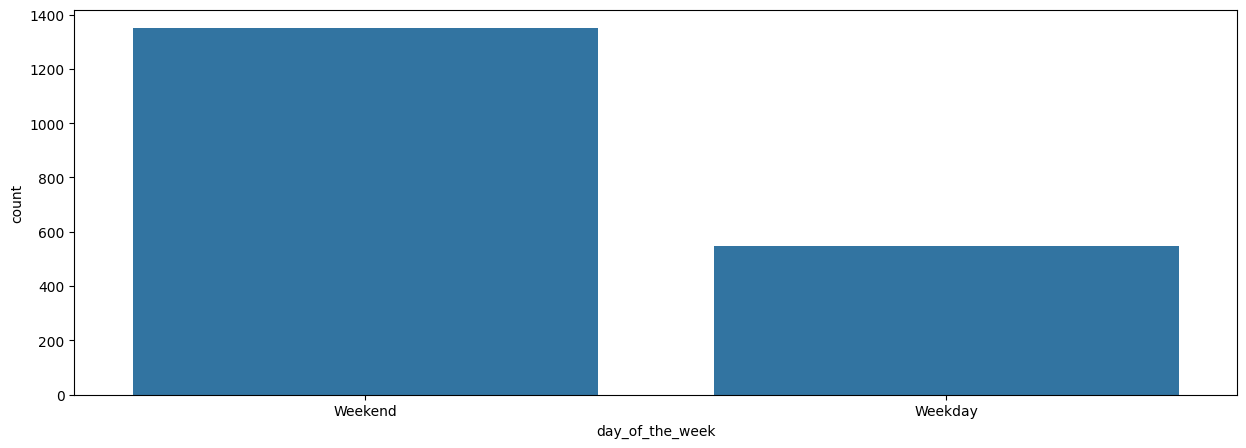

In [12]:
plt.figure(figsize = (15,5))
sns.countplot(data = df, x = 'day_of_the_week');

###**`Observations:`**

*   Day of the week has categorized between Weedays and Weekends.
*   Weekends have more orders than weekdays.



###**`Rating`**

In [13]:
# Check the unique values of Ratings
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


<Axes: xlabel='rating', ylabel='count'>

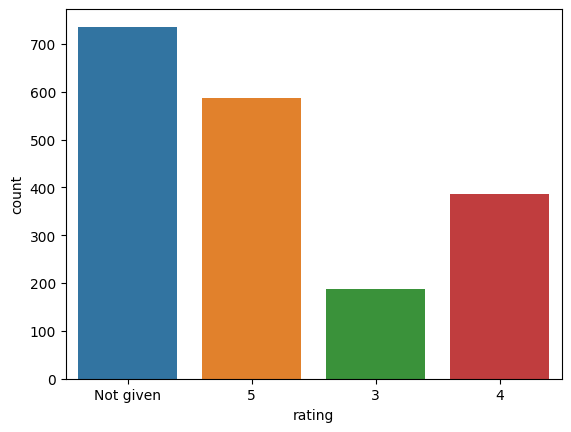

In [30]:
# Visualize the different ratings given by customers
sns.countplot(data = df, x = 'rating',hue='rating')

###**`Observations:`**
There are 736 times when rating has not been provided by customers.

###**`Food Preparation Time`**

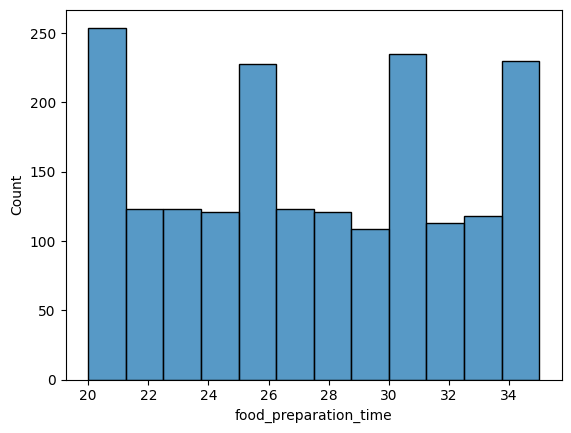

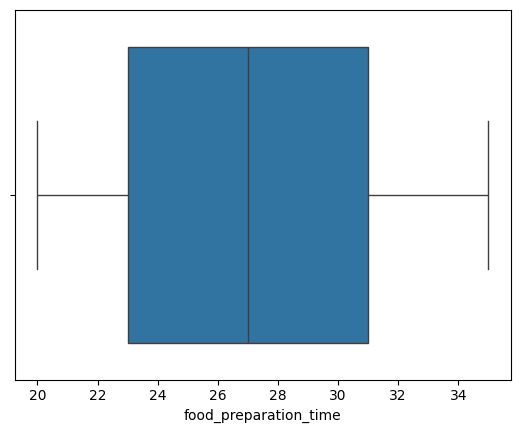

In [101]:
# Visualize and anlayze the food preparation time
sns.histplot(data=df,x='food_preparation_time')
plt.show()
sns.boxplot(data=df,x='food_preparation_time')
plt.show()

###**`Observations:`**


*   The minimum food preparation time is 20 minutes, Q1 (Quantile 25%) is 23 minutes, median is 27 minutes, Q3(Quantile 75%) is 31 minutes and maximum is 35 minutes.There are no outliers in food prepartion time.


###**`Delivery Time`**

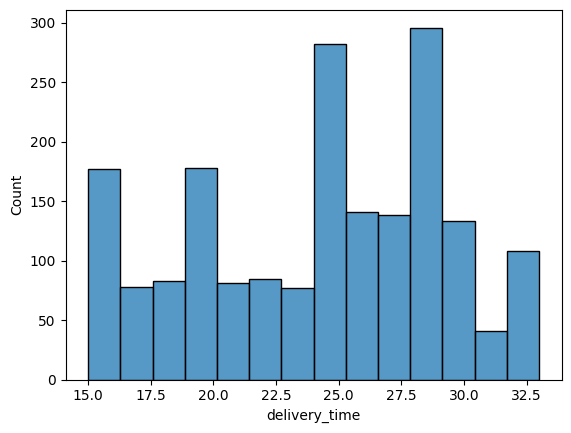

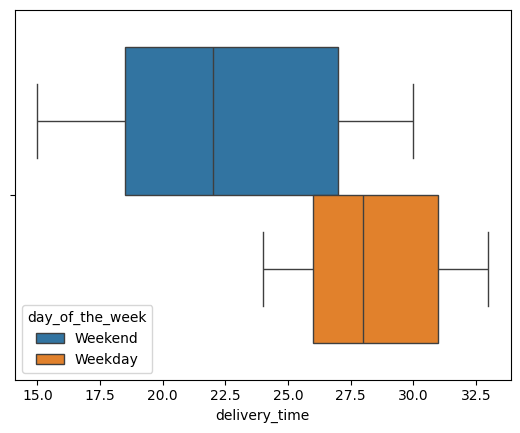

In [105]:
sns.histplot(data=df,x='delivery_time')
plt.show()
sns.boxplot(data=df,x='delivery_time',hue='day_of_the_week')
plt.show()

###**`Observations:`**

*   The delivery time is negatively skewed (skewed left)
*   The median delivery time is more on weekdays which is around 28 minutes than weekends which is around 22 minutes.



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# To check the top 5 restaurants in terms of the number of orders received
df['restaurant_name'].value_counts().head()

,restaurant_name
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:


* Shack Shack is the most popular restaurant based on the number of orders received.
*  The top restaurants in terms of the number of orders received are: Shake Shack,The Meatball Shop,Blue Ribbon Sushi,Blue Ribbon Fried Chicken and Parm.



### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [20]:
# Filter the orders which were placed on weekend
day_of_the_weekend =df[df['day_of_the_week']=='Weekend']
# Get the most popular cuisine placed on weekend
day_of_the_weekend['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


#### Observations:


American cuisine type is the most popular during weekends based on the count of orders.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [19]:
# Filter the cost_of_orders greater then $20, then calulate the percentage of those orders based on total orders.
cost_of_order=df[df['cost_of_the_order']>20].shape[0]/df.shape[0]*100
print(f'The percentage of orders having cost greater than $20 is : {cost_of_order}%')

The percentage of orders having cost greater than $20 is : 29.24130663856691%


#### Observations:


The percentage of orders having cost greater than $20 is : 29.24130663856691%

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Get the mean Delivery Time (in min)
df['delivery_time'].mean()

24.161749209694417

#### Observations:


The mean delivery time of the orders is 24.161749209694417 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Get the Top 3 most frequent customer ids based on the number of orders placed.
df['customer_id'].value_counts().head(3)

,customer_id
52832,13
47440,10
83287,9


#### Observations:


The 3 top frequent customers who ordered the most are Customer IDs: 52832, 47440, 83287.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


###**`Cuisine vs Cost of the order`**

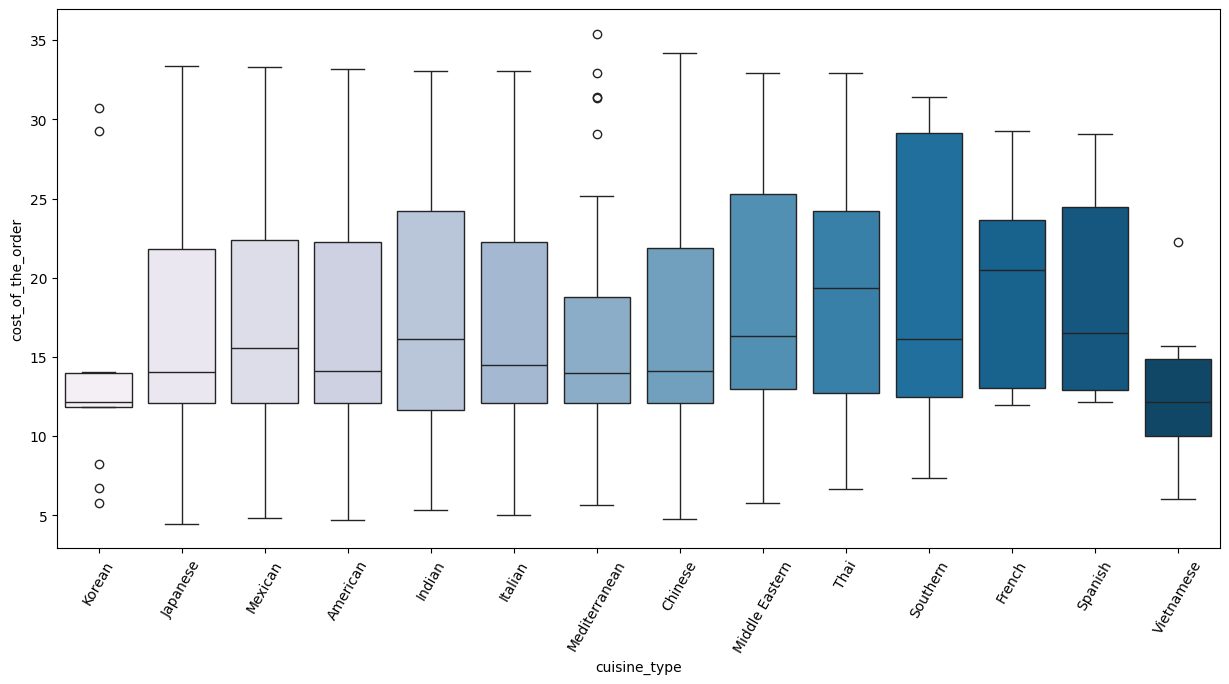

In [86]:
# Relationship between cost of the order and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu', hue = "cuisine_type")
plt.xticks(rotation = 60)
plt.show()

###**`Observations:`**

*   Chinese cuisine has the highest cost of order.
*   There are outliers for Korean, Mediterranean and Vietnamese cuisine for cost of the order which are unusually high or low cost.
*   Most of the cuisines have cost of the order as positively skewed.
*   French cuisine cost of order is negatively skewed.





###**`Cuisine vs Food Preparation time`**

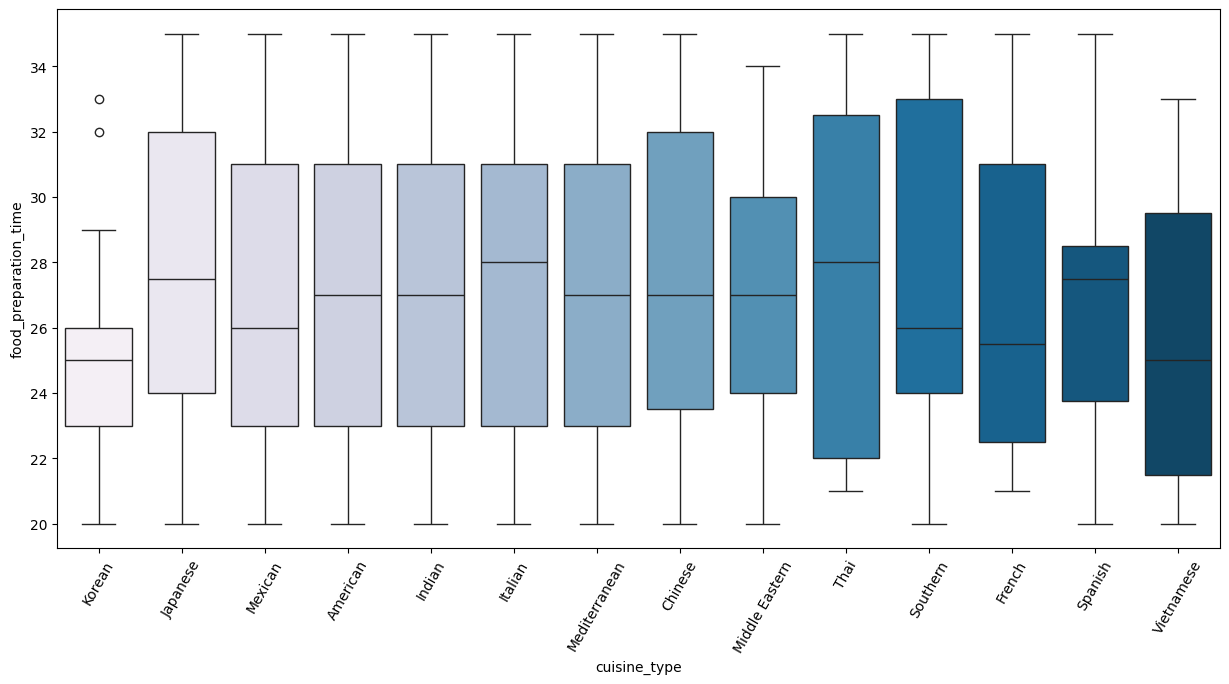

In [90]:
# Relationship between food preparation time and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "food_preparation_time", data = df, palette = 'PuBu', hue = "cuisine_type")
plt.xticks(rotation = 60)
plt.show()

###**`Observations:`**

*   Italian and Thai have the highest median food preparation time while Korean and Vietnames have the least median preparation time.
*   There are outliers for Korean cuisine food preparation time.
*   The Korean and Spanish cuisine are negatively skewed with respect to food preparation time.






###**`Day of the Week vs Delivery time`**

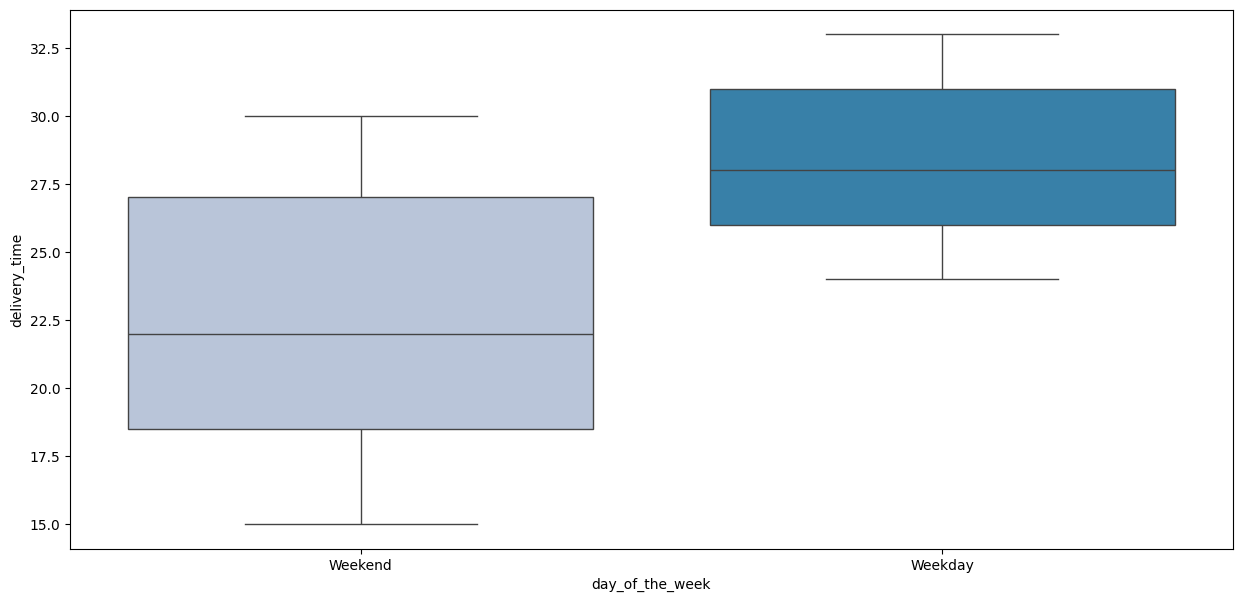

In [92]:
# Relationship between day of the week and delivery time
plt.figure(figsize=(15,7))
sns.boxplot(x = "day_of_the_week", y = "delivery_time", data = df, palette = 'PuBu', hue = "day_of_the_week")
plt.show()

In [110]:
df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(5)

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76


###**`Observations:`**

*   Weekday delivery times are higher then weekend delivery times.
*   The top 5 restaurant in terms of revenue are Shack Shack, The Meatball Shop, Blue Ribbon Sushi, Blue ribbon Fried Cheicken and Parm.



###**`Rating vs Delivery time`**

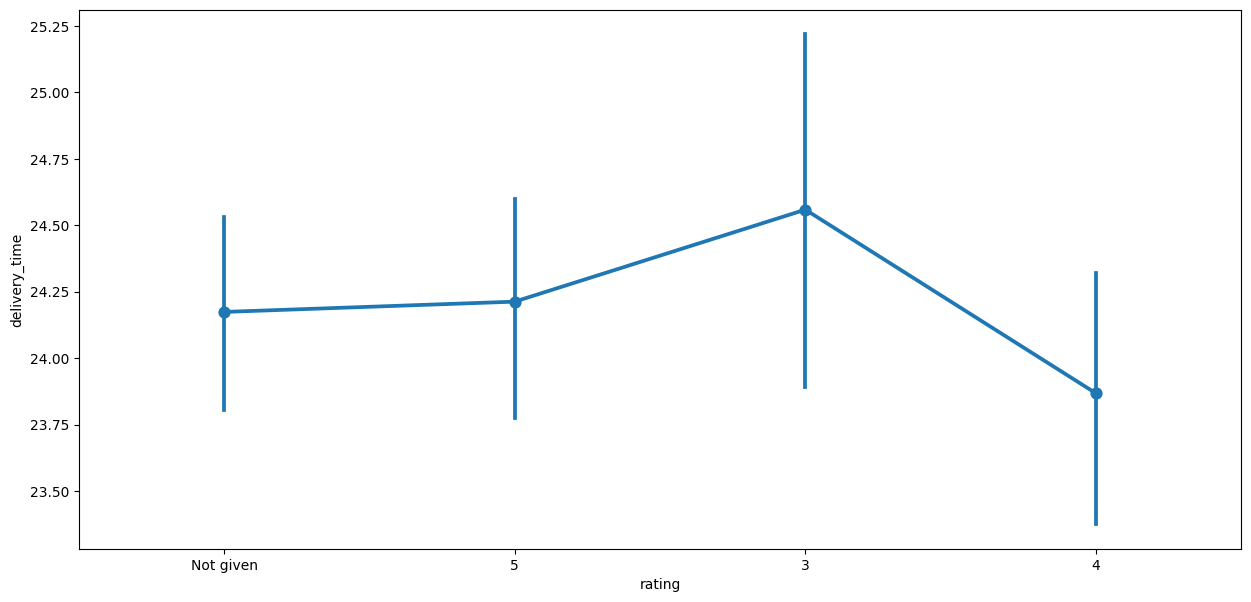

In [94]:
# Relationship between rating and delivery time
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'delivery_time', data = df)
plt.show()

###**`Observations:`**

*   Lower delivery time of the orders are receiving ratings of 4 and more.
*   3 is the general rating for higher delivery time.



###**`Rating vs Food preparation time`**

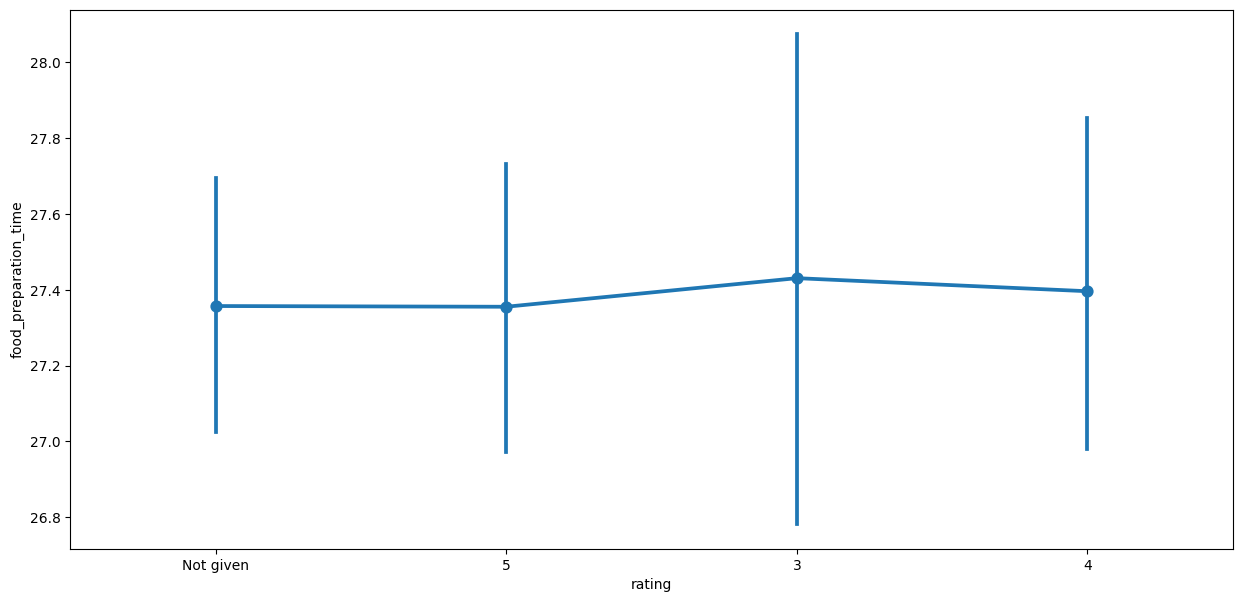

In [95]:
# Relationship between rating and food preparation time
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'food_preparation_time', data = df)
plt.show()

###**`Observations:`**

*   Lower food preparation time of the orders are receiving ratings of 4 and more.
*   3 is the general rating for food preparation time of around 27.5 minutes.






###**`Rating vs Cost of the order`**

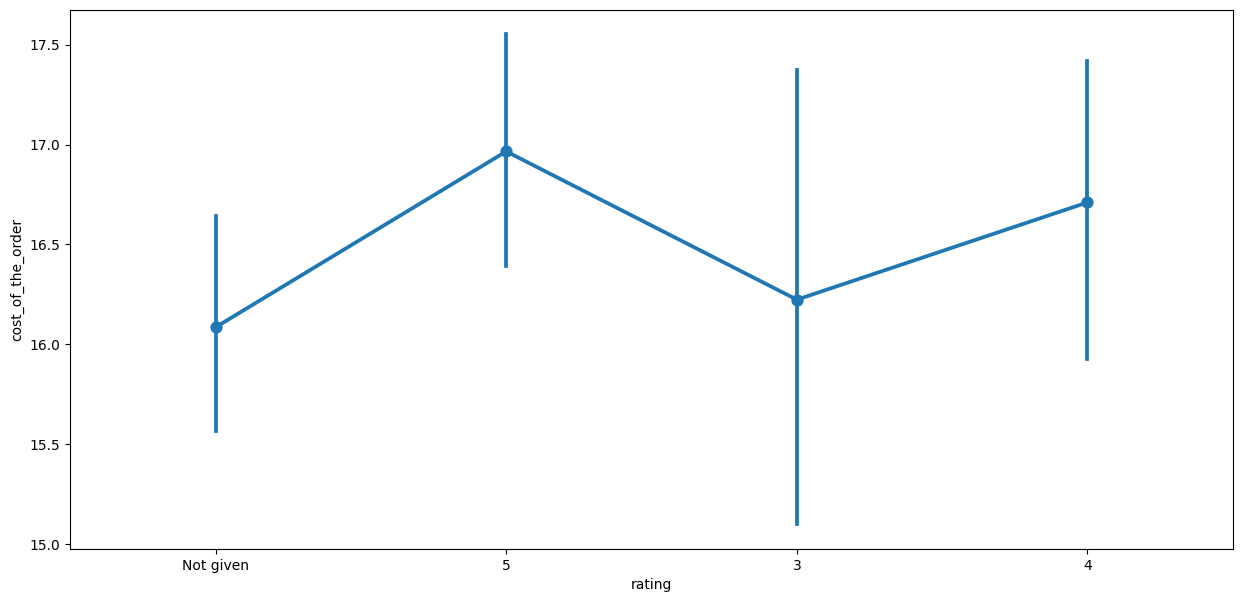

In [96]:
# Relationship between rating and cost of the order
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'cost_of_the_order', data = df)
plt.show()

###**`Observations:`**

*   Cost of the order value is higher for ratings of 5.


###**`Correlation among variables`**

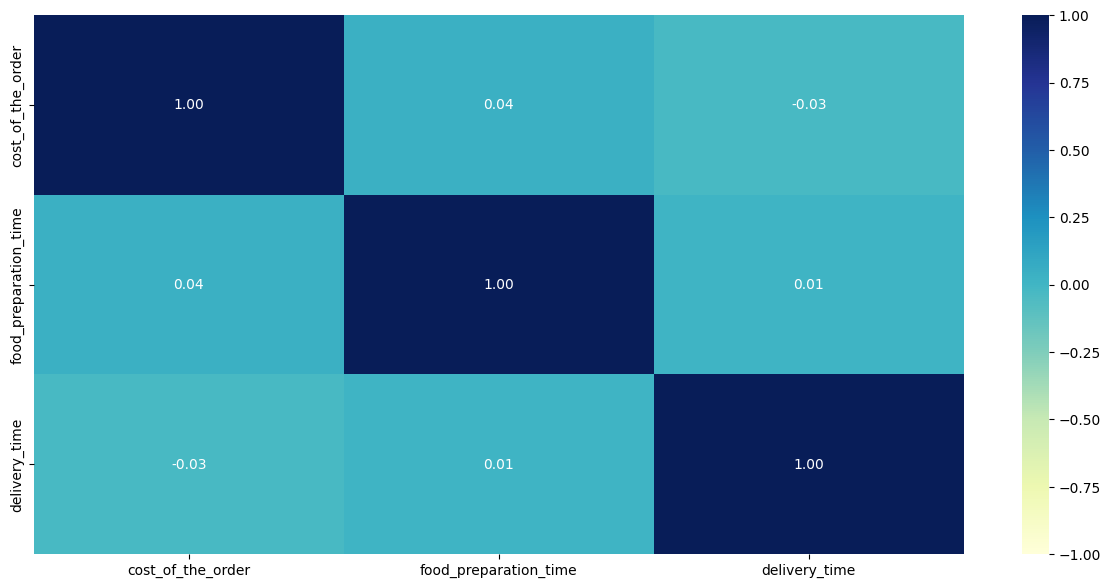

In [111]:
# Plot the heatmap
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="YlGnBu")
plt.show()

###**`Observations:`**

*   There is positive correlation between cost of order and food preparation time.
*   There is a negative correlation between cost of order delivery time.




### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [66]:
# Filter out the restaurants which are not rated
df_rest_rated = df[df['rating'] != 'Not given'].copy()

# Convert rating column from object to integer
df_rest_rated['rating'] = df_rest_rated['rating'].astype('int')

# Create a dataframe that contains the restaurant names with their rating counts
df_rest_rating_count = df_rest_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()

# Get the restaurant names that have rating count more than 50
rest_names = df_rest_rating_count[df_rest_rating_count['rating'] > 50]['restaurant_name']

# Create a dataframe copy to get the data of restaurants that have rating count more than 50
df_rest_rated_50 = df_rest_rated[df_rest_rated['restaurant_name'].isin(rest_names)].copy()

# Group the restaurant names with their ratings and find the mean rating of each restaurant
df_mean_4_rating = df_rest_rated_50.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index().dropna()

# filter for average rating greater than 4
df_avg_rating_greater_than_4 = df_mean_4_rating[df_mean_4_rating['rating'] > 4].sort_values(by='rating', ascending=False).reset_index(drop=True)

print(df_avg_rating_greater_than_4)


             restaurant_name    rating
0          The Meatball Shop  4.511905
1  Blue Ribbon Fried Chicken  4.328125
2                Shake Shack  4.278195
3          Blue Ribbon Sushi  4.219178


#### Observations:


There are 4 restaurants fulfilling the criteria to get the promotional offer which have more than 50 ratings and and average rating more than 4.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [65]:
#function to determine the revenue
def calc_rev(x):
    if x > 20:
        return x*0.25
    elif x > 5:
        return x*0.15
    else:
        return x*0

df['Revenue'] = df['cost_of_the_order'].apply(calc_rev)

# Calculate the total net revenue generated across all orders
total_net_rev = df['Revenue'].sum()
print('The net revenue is around', round(total_net_rev,2),'dollars')

The net revenue is around 6166.3 dollars


#### Observations:


The net revenue generated by the company across all orders is $6166.30.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [75]:
# Calculate total delivery time by adding food_preparation_time and the delivery_time
# Add a new column total_time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Filter the total_time greater then 60 min, then calulate the percentage of those orders based on total orders.
total_delivery_time=df[df['total_time']>60].shape[0]/df.shape[0]*100

#Print the percentage.
print('The percentage of orders that take more then 60 minutes to get delivered from the time order is placed :', round(total_delivery_time,2) ,'%')

The percentage of orders that take more then 60 minutes to get delivered from the time order is placed : 10.54 %


#### Observations:


The percentage of orders that take more then 60 minutes to get delivered from the time the order is placed is 10.537407797681771%

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [85]:
# Calculate the mean delivery time on weekdays.
df_weekday=round(df[df['day_of_the_week']=='Weekday']['delivery_time'].mean())

# Print the delivery time of the orders on weekdays
print('The mean delivery time on weekdays is around', round(df_weekday),'minutes')

# Calculate the mean delivery time on weekdays.
df_weekend=round(df[df['day_of_the_week']=='Weekend']['delivery_time'].mean())

# Print the delivery time of the orders on weekends
print('The mean delivery time on weekends is around', round(df_weekend),'minutes')

The mean delivery time on weekdays is around 28 minutes
The mean delivery time on weekends is around 22 minutes


#### Observations:


The mean delivery time on weekdays is around 28 minutes.
The mean delivery time on weekends is around 22 minutes.
The mean delivery time is more during weekdays than on weekends.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

We analyzed a dataset of nearly 2K orders from New York restaurants. We focuused on analyzing mainly on ratings provided by customers,order volume of each customer, food preparation time, food delivery time and cost of orders.

We have been able to conclude that -

*  There are no missing values in the data.
*  The time it takes to prepare the food once order is placed: Minimum Time (in minutes) - 20.0 minutes Average Time (in minutes) - 27.37197 minutes Maximum Time (in minutes) - 35.0 minutes
*  The American cuisine is the most popular cuisine ordered in weekdays and weekends
*   The Vietnamese cuisine is the least ordered cuisine.
*   Top 3 ordered cuisines are American, Japanese and Italian.
*   Weekday delivery times are higher then weekend delivery times.
*   The top 5 restaurant in terms of revenue are Shack Shack, The Meatball Shop, Blue Ribbon Sushi, Blue ribbon Fried Cheicken and Parm.
*   The percentage of orders that take more then 60 minutes to get delivered from the time the order is placed is around 10.54%
*   There is positive correlation between cost of order and food preparation time.
*   There is a negative correlation between cost of order delivery time.















### Recommendations:

*  The focus should be to provide more promotional offers for cuisines like Korean, Spanish, Vietnamese which will perhaps drive more orders and increase customer ratings which will help in increasing the cost of orders.
*   Restaurants catering to American, Japanese and Italian should provide more promotional offers to drive revenue growth.
*   Weekday delivery time should be reduced to drive ratings from customers and be near to weekend delivery times.
*   Customers should be encouraged to provide ratings which will help in increasing cost of the order as higher ratings help in increasing revenue for the restaurants.






---